In [1]:
!pip install datasets

In [2]:
import os
import json
from datasets import load_dataset
from PIL import Image
from tqdm import tqdm

TRAIN_DIR = "/kaggle/working/plan_b_train_data"
TARGET_SIZE = 1024  # Upscale target for SSD-1B
os.makedirs(TRAIN_DIR, exist_ok=True)

# 1. Download directly from Hugging Face
print("Downloading pixel-art-nouns-2k from Hugging Face...")
dataset = load_dataset("jiovine/pixel-art-nouns-2k", split="train")

metadata = []
print(f"Upscaling {len(dataset)} images using Nearest Neighbor...")

for i, item in enumerate(tqdm(dataset)):
    try:
        # HF datasets automatically load images as PIL objects
        img = item["image"]

        # The text column in this specific dataset is usually 'text'
        # Add the mandatory style trigger here to prevent catastrophic forgetting
        caption = "pixel art style, " + item["text"]

        if img.mode != "RGB":
            img = img.convert("RGB")

        # 2. Crucial Step: Nearest Neighbor upscaling to keep pixels sharp
        img_upscaled = img.resize((TARGET_SIZE, TARGET_SIZE), resample=Image.NEAREST)

        filename = f"noun_{i}.png"
        img_upscaled.save(os.path.join(TRAIN_DIR, filename), "PNG")

        metadata.append({"file_name": filename, "text": caption})

    except Exception as e:
        print(f"Skipping image {i} due to error: {e}")

# 3. Save the JSONL file for the trainer
with open(os.path.join(TRAIN_DIR, "metadata.jsonl"), "w") as f:
    for entry in metadata:
        f.write(json.dumps(entry) + "\n")

print(f"Plan B Data Ready! Saved to {TRAIN_DIR}")

README.md:   0%|          | 0.00/400 [00:00<?, ?B/s]

data/train-00000-of-00001-6c76be0228a05d(…):   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Upscaling 2000 images using Nearest Neighbor...


100%|██████████| 2000/2000 [01:20<00:00, 24.91it/s]

Plan B Data Ready! Saved to /kaggle/working/plan_b_train_data


In [3]:
# import matplotlib.pyplot as plt
# from PIL import Image
# import os

# # Path to your newly processed Plan B dataset
# TRAIN_DIR = "/kaggle/working/plan_b_train_data"

# # Grab the very first image we processed
# sample_image_path = os.path.join(TRAIN_DIR, "noun_0.png")

# if os.path.exists(sample_image_path):
#     img = Image.open(sample_image_path)
    
#     # Display the image
#     plt.figure(figsize=(8, 8))
#     plt.imshow(img)
#     plt.title(f"Upscaled Resolution: {img.size[0]}x{img.size[1]} pixels\n(Notice the crisp edges!)", fontsize=14)
#     plt.axis('off') # Hides the axis numbers for a cleaner look
#     plt.show()
# else:
#     print("Image not found. Make sure the Plan B Data Prep cell has finished running completely!")

In [4]:
# Install the necessary libraries
!pip install -U -q diffusers accelerate transformers peft bitsandbytes
!pip install -q wandb # For metric identification and tracking

# Download the official training script for SDXL/SSD-1B
!wget https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora_sdxl.py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00
--2026-03-24 06:09:23--  https://raw.githubusercontent.com/huggingface/diffusers/main/examples/text_to_image/train_text_to_image_lora_sdxl.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 56285 (55K) [text/plain]
Saving to: ‘train_text_to_image_lora_sdxl.py’

train_text_to_image 100%[===================>]  54.97K  --.-KB/s    in 0.01s   

2026-03-24 06:09:23 (4.33 MB/s) - ‘train_text_to_image_lora_sdxl.py’ saved [56285/56285]



In [5]:
# 1. Uninstall existing version to avoid conflicts
!pip uninstall -y diffusers

# 2. Install the latest "dev" version from source
!pip install git+https://github.com/huggingface/diffusers

# 3. Ensure other dependencies are up to date for SSD-1B
!pip install -U -q accelerate transformers peft bitsandbytes

Found existing installation: diffusers 0.37.0
Uninstalling diffusers-0.37.0:
  Successfully uninstalled diffusers-0.37.0
  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-o2pw2cwf
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-o2pw2cwf
  Resolved https://github.com/huggingface/diffusers to commit 6350a7690ae2f1bc98f3248ccfb496a4c4184d2c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-py3-none-any.whl size=5084528 sha256=4db409d87e7f424e5f059cfa17678452e87401b6b84a762d09e4c472f323cfac
  Stored in directory: /tmp/pip-ephem-wheel-cache-bd2ec30p/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers


# Root Cause Analysis & Fix (v2 — No Style Prefix)

## Context
- **Dataset:** `jiovine/pixel-art-nouns-2k` — 2,000 pixel art images, natively **256×256**
- **Captions:** Plain descriptions like *"a character with square black glasses, a hotdog-shaped head…"* — **no style prefix**
- **Goal:** Generate **256×256 pixel art** matching these descriptions
- **Training pipeline:** Images upscaled 256→1024 (nearest neighbor) for SSD-1B, generate at 1024, then **downscale back to 256×256** (nearest neighbor)

---

## What went wrong with the original training

### 1. Learning Rate WAY Too High (`1e-4`)
**#1 cause.** For SDXL/SSD-1B LoRA, `1e-4` is extremely aggressive. Recommended: **`1e-5`**. At `1e-4`, LoRA adapters overpower the base model's text understanding:
- "Circular glasses" → generates square (dataset's dominant pattern overwrites text grounding)
- Colors approximate but not accurate
- Classic **catastrophic forgetting via LoRA overshoot**

### 2. Missing `--snr_gamma=5.0` (Min-SNR Loss Weighting)
Without this, MSE loss is dominated by high-noise timesteps. The model wastes capacity on denoising near-pure-noise instead of learning fine details (glasses shape, colors, body features). Critical for a dataset where distinctions are subtle (circular vs. square glasses, specific colors).

### 3. No Style Prefix — LoRA Must Learn Style Purely From Images
Since captions are plain descriptions with no "pixel art" trigger, the LoRA is the **sole carrier of the pixel art style**. This makes training more sensitive to hyperparameters:
- The LoRA must simultaneously learn: (a) pixel art visual style, AND (b) correct text→attribute mappings
- At inference, there's no textual cue for pixel art — only the LoRA weights steer toward that style
- **This makes LoRA scale at inference even more critical** (too low = no pixel art, too high = text ignored)

### 4. Constant LR Schedule With 50% Warmup
Default `lr_scheduler="constant"` with `lr_warmup_steps=500` out of 1000 total steps = model does nothing for the first 50%. **Cosine schedule** with short warmup decays gracefully, preventing late-stage overfitting.

### 5. Too Many Effective Epochs at High LR
- Effective batch size = `2 × 8 = 16`
- Steps per epoch = `2000 / 16 = 125` optimizer steps
- 1000 steps ÷ 125 = **8 epochs** at aggressive LR → heavy overfitting to the mode

### 6. Missing `--noise_offset=0.1`
Pixel art has stark contrasts (pure black outlines, saturated colors, solid backgrounds). Without noise offset, the model can't properly learn very dark/light pixel values.

### 7. `image_interpolation_mode` defaulting to Lanczos
Training script re-resizes internally using Lanczos. Since we upscaled with nearest neighbor, internal re-resize should also use nearest to avoid blurring pixel edges.

### 8. Inference: Missing 256×256 Downscale
SSD-1B generates at 1024×1024. Since your target is 256×256 pixel art, you must **downscale the output back to 256×256 using nearest-neighbor** — this restores the crisp pixel-art look and matches the training distribution.

### 9. Inference Settings Too Aggressive
- `guidance_scale=7.5` is too high for LoRA (amplifies LoRA biases) → use **4.0–5.5**
- `num_inference_steps=25` is too few for quality → use **40+**

---

## Fixed Training & Inference Below ↓

In [6]:
# ============================================================
# W&B Setup — load API key from Kaggle Secrets and login
# Make sure you've added your W&B API key as a Kaggle Secret
# with the label "WANDB" (Add-ons → Secrets in notebook sidebar)
# ============================================================
import os
import wandb
from kaggle_secrets import UserSecretsClient

wandb_api_key = UserSecretsClient().get_secret("WANDB")
wandb.login(key=wandb_api_key)

# Set the W&B project name so the training script picks it up
os.environ["WANDB_PROJECT"] = "Pixel Art"

print("Logged into W&B successfully. Project: 'Pixel Art'")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nhr13 (nhr13-bangladesh-university-of-engineering-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Logged into W&B successfully. Project: 'Pixel Art'


In [7]:
# ============================================================
# FIXED TRAINING COMMAND (v3 — re-added style prefix + net alpha)
# 
# Captions now use "pixel art style," prefix to prevent
# catastrophic forgetting.
#
# Key changes from original:
#   1. learning_rate:     1e-4  → 5e-6    (lower, prevents catastrophic forgetting)
#   2. snr_gamma:         None  → 5.0     (Min-SNR weighting — detail-level learning)
#   3. lr_scheduler:      const → cosine  (graceful decay, no late-stage overfitting)
#   4. lr_warmup_steps:   500   → 100     (shorter warmup = more productive steps)
#   5. noise_offset:      0     → 0.1     (better dark/light pixel handling)
#   6. max_train_steps:   1000  → 1500    (more steps at lower LR)
#   7. gradient_checkpointing: enabled    (frees VRAM)
#   8. image_interpolation_mode: nearest  (matches NN upscale preprocessing)
#   9. validation_prompt: modified to include style trigger
#  10. Multi-GPU:         num_processes=2 and grad_accum=4 for T4x2 Kaggle setup.
# 
# Note: `--network_alpha` was removed because the official huggingface script 
# internally hardcodes `lora_alpha` to equal `--rank`, which gives us exactly
# the 1.0 ratio we want by default anyway!
# ============================================================

!accelerate launch --num_processes=2 train_text_to_image_lora_sdxl.py \
  --pretrained_model_name_or_path="segmind/SSD-1B" \
  --pretrained_vae_model_name_or_path="madebyollin/sdxl-vae-fp16-fix" \
  --train_data_dir="/kaggle/working/plan_b_train_data" \
  --caption_column="text" \
  --resolution=1024 \
  --mixed_precision="fp16" \
  --train_batch_size=2 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --learning_rate=5e-6 \
  --lr_scheduler="cosine" \
  --lr_warmup_steps=100 \
  --snr_gamma=5.0 \
  --noise_offset=0.1 \
  --rank=16 \
  --max_train_steps=1500 \
  --checkpointing_steps=250 \
  --validation_prompt="pixel art style, a character with square black glasses, a hotdog-shaped head and a peachy-colored body on a warm background" \
  --validation_epochs=1 \
  --num_validation_images=4 \
  --image_interpolation_mode="nearest" \
  --output_dir="/kaggle/working/court_of_owls_lora_v3" \
  --seed=42 \
  --report_to="wandb"

The following values were not passed to `accelerate launch` and had defaults used instead:
		More than one GPU was found, enabling multi-GPU training.
		If this was unintended please pass in `--num_processes=1`.
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to

In [8]:
# import torch
# from diffusers import DiffusionPipeline
# import matplotlib.pyplot as plt
# import os

# # Load the base model
# pipe = DiffusionPipeline.from_pretrained(
#     "segmind/SSD-1B",
#     torch_dtype=torch.float16,
#     variant="fp16"
# )
# pipe.to("cuda")

# # Load your trained LoRA weights
# pipe.load_lora_weights("/kaggle/working/court_of_owls_lora_plan_b/pytorch_lora_weights.safetensors")

# # Generate test images
# prompts = [
# "a character with circular blue glasses, a square-shaped head and a teal-colored body on a cool background"
# ]

# images = []
# for prompt in prompts:
#     image = pipe(
#         prompt=prompt,
#         num_inference_steps=25,
#         guidance_scale=7.5,
#         generator=torch.Generator("cuda").manual_seed(42)
#     ).images[0]
#     images.append(image)

# # Display results
# # fig, axes = plt.subplots(1, 4, figsize=(20, 5))
# # for ax, img, prompt in zip(axes, images, prompts):
# #     ax.imshow(img)
# #     ax.set_title(prompt, fontsize=10)
# #     ax.axis('off')
# # plt.tight_layout()
# plt.figure(figsize=(8, 8))
# plt.imshow(image)
# plt.title("LoRA Generalization Test", fontsize=16, fontweight='bold')
# plt.axis('off') # Hides the grid numbers for a clean presentation
# plt.tight_layout()
# plt.show()

# # Create output directory and save
# os.makedirs("/kaggle/working/output", exist_ok=True)
# plt.savefig("/kaggle/working/output/validation_results.png")
# plt.show()

# print("Images saved to: /kaggle/working/output/validation_results.png")

In [9]:
%%writefile validation_metrics.py

import numpy as np
from PIL import Image
from sklearn.cluster import KMeans

def calculate_color_count(image: Image.Image) -> int:
    """Calculate the number of unique colors in an image."""
    img_array = np.array(image.convert("RGB"))
    unique_colors = np.unique(img_array.reshape(-1, img_array.shape[-1]), axis=0)
    return len(unique_colors)

def check_grid_adherence(image: Image.Image, block_size: int = 4) -> float:
    """
    Calculate the percentage of block_size x block_size uniform blocks.
    A score of 100% means the image perfectly adheres to the pixel-art grid.
    """
    img_array = np.array(image.convert("RGB"))
    h, w, c = img_array.shape
    
    # Trim to perfectly fit blocks
    h = (h // block_size) * block_size
    w = (w // block_size) * block_size
    img_array = img_array[:h, :w]
    
    blocks = img_array.reshape(h // block_size, block_size, w // block_size, block_size, c)
    blocks = blocks.swapaxes(1, 2)  # shape: (blocks_h, blocks_w, block_size, block_size, c)
    
    # Check if all pixels in a block are exactly the same as the top-left pixel
    top_lefts = blocks[:, :, 0:1, 0:1, :]
    
    # boolean array if elements in block equal their top-left element
    is_uniform = np.all(blocks == top_lefts, axis=(2, 3, 4))
    
    return float(np.mean(is_uniform) * 100.0)

def apply_kmeans_palette(image: Image.Image, n_colors: int = 32) -> Image.Image:
    """
    Post-processing B: Snap continuous colors back to a strict K-means palette.
    """
    img_array = np.array(image.convert("RGB"))
    h, w, c = img_array.shape
    
    pixels = img_array.reshape(-1, c)
    
    # If the image already has fewer or equal colors, return it
    if len(np.unique(pixels, axis=0)) <= n_colors:
        return image
    
    # Use MiniBatchKMeans or standard KMeans
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init='auto').fit(pixels)
    new_pixels = kmeans.cluster_centers_[kmeans.labels_].astype(np.uint8)
    
    new_img_array = new_pixels.reshape(h, w, c)
    return Image.fromarray(new_img_array, mode="RGB")


Writing validation_metrics.py


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


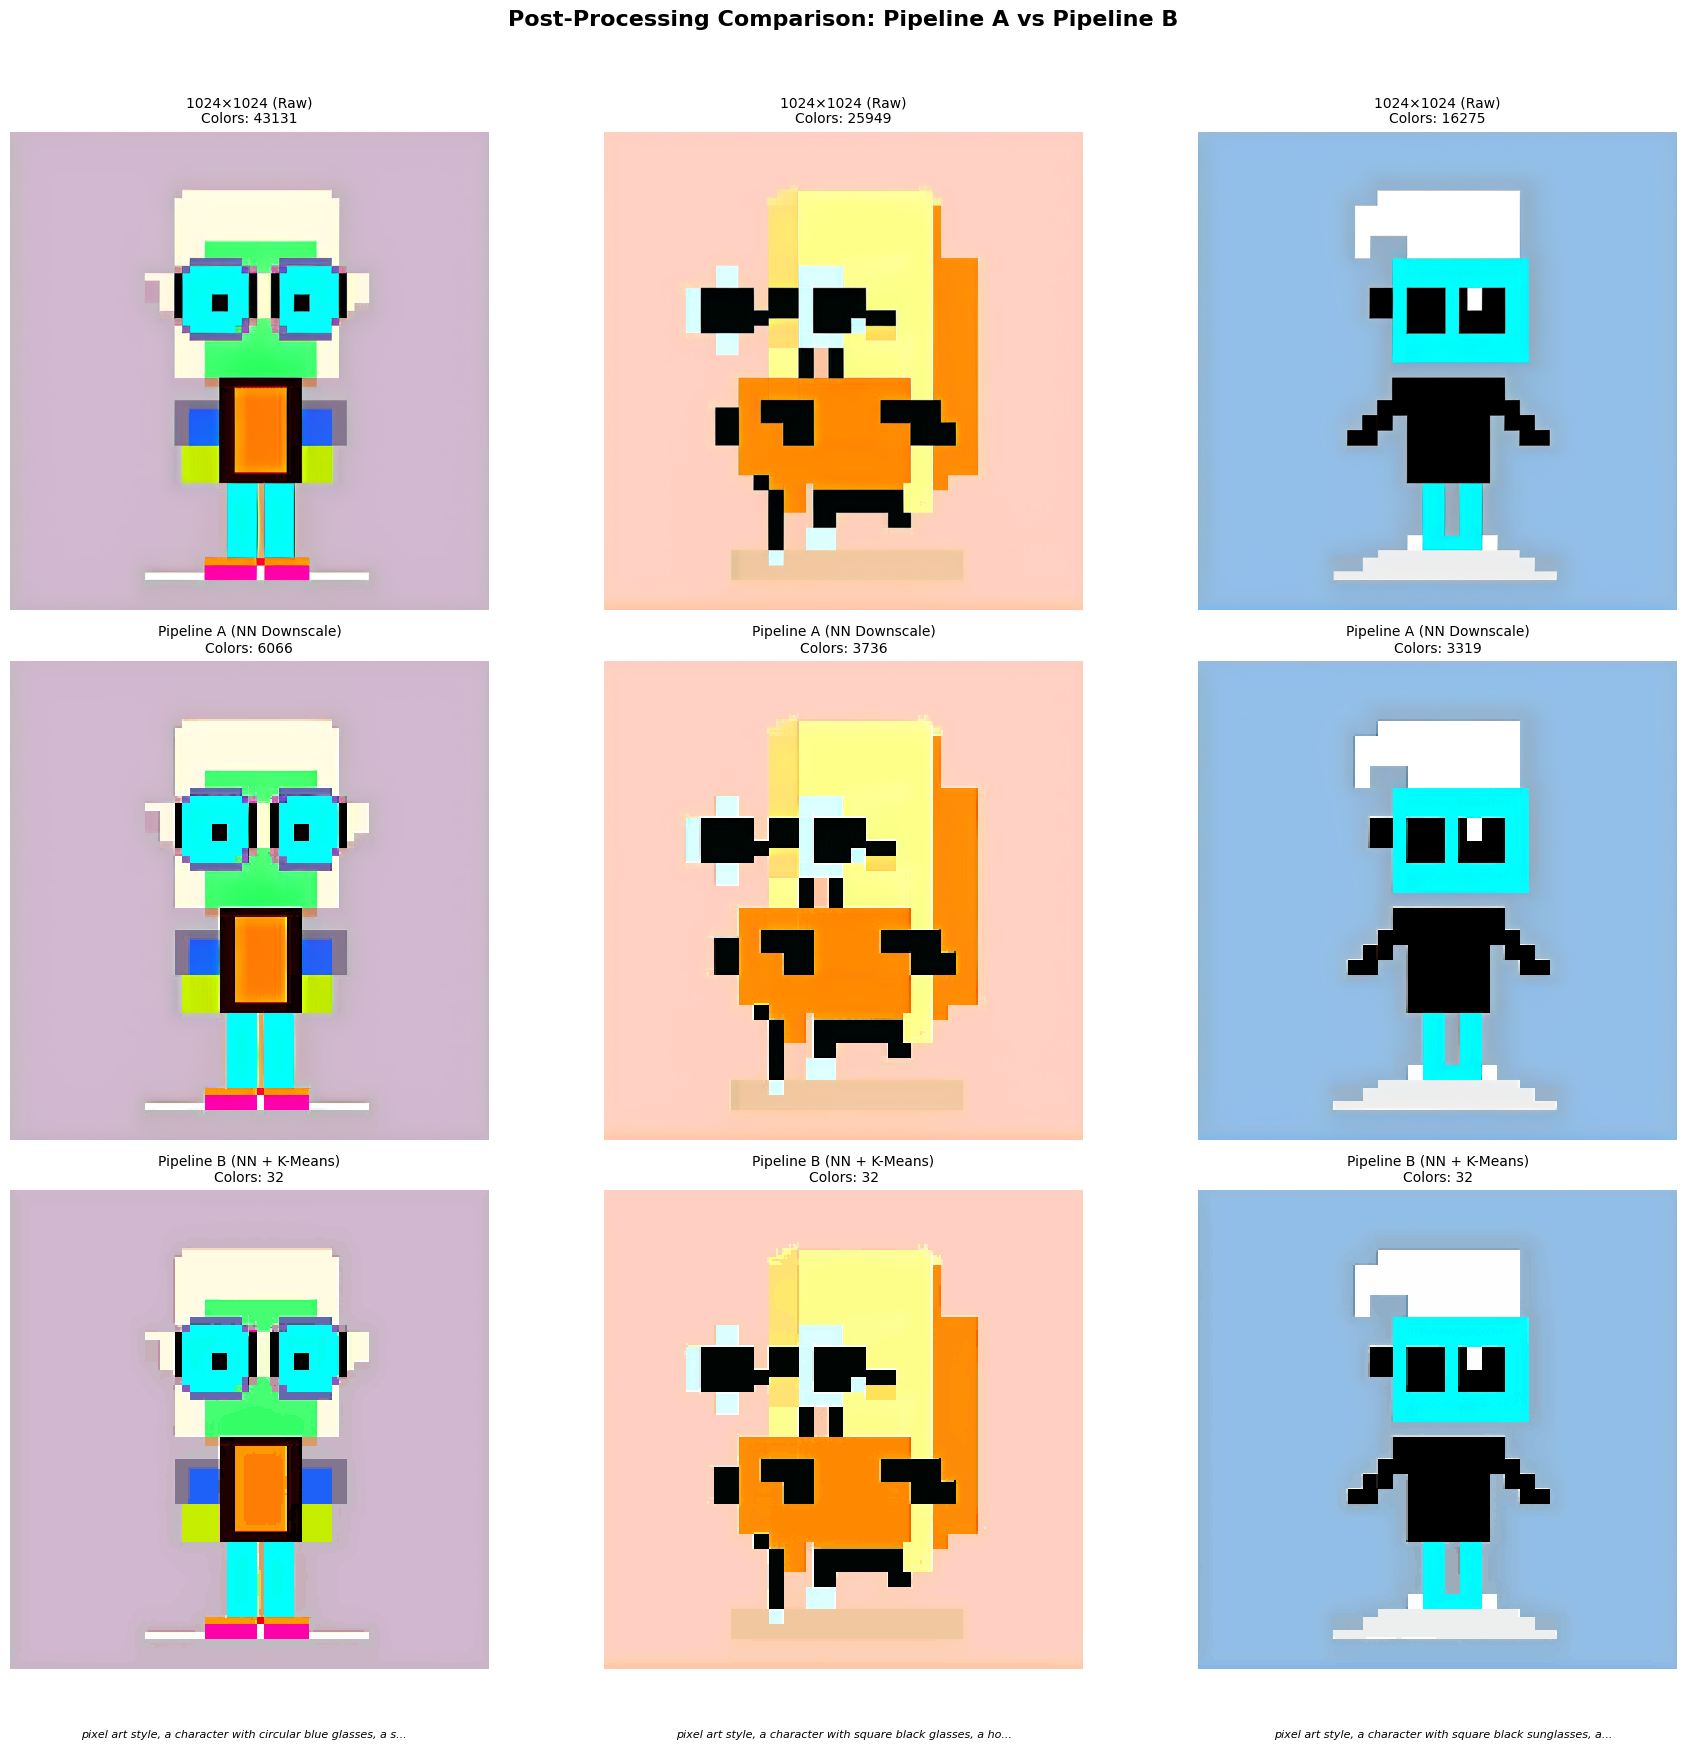

Grid saved to: /kaggle/working/output/pipeline_comparison.png


In [10]:
import torch
from diffusers import DiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt
import os
import sys

# Load custom metrics for pipeline B
from validation_metrics import apply_kmeans_palette, calculate_color_count, check_grid_adherence

# 1. Load the base model
pipe = DiffusionPipeline.from_pretrained(
    "segmind/SSD-1B",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe.to("cuda")

# 2. Load LoRA weights with scaling
# USING V3 - the version with trigger word and network_alpha
lora_path = "/kaggle/working/court_of_owls_lora_v3/pytorch_lora_weights.safetensors"
if os.path.exists(lora_path):
    pipe.load_lora_weights(lora_path, adapter_name="pixel_art")
    # Scale LoRA influence (0.7–0.9 = style + text balance)
    pipe.set_adapters(["pixel_art"], adapter_weights=[0.8])
    print("LoRA weights loaded with scale=0.8")
else:
    print("Warning: LoRA weights not found at the specified path!")

# 3. Prompts — now WITH the style trigger prefix
prompts = [
    "pixel art style, a character with circular blue glasses, a square-shaped head and a teal-colored body on a cool background",
    "pixel art style, a character with square black glasses, a hotdog-shaped head and a peachy-colored body on a warm background",
    "pixel art style, a character with square black sunglasses, a shower-shaped head and a blue-colored body on a cool background",
]

# 4. Generate at 1024×1024 then run post-processing pipelines
TARGET_OUTPUT_SIZE = 256
images_1024 = []
images_pipeline_a = [] # Nearest Neighbor only
images_pipeline_b = [] # Nearest Neighbor + K-means

print("Generating images and comparing post-processing pipelines...")

for prompt in prompts:
    img_1024 = pipe(
        prompt=prompt,
        num_inference_steps=40,
        guidance_scale=5.0,
        generator=torch.Generator("cuda").manual_seed(42)
    ).images[0]
    images_1024.append(img_1024)
    
    # Pipeline A: Downscale to 256×256 using nearest neighbor
    img_a = img_1024.resize((TARGET_OUTPUT_SIZE, TARGET_OUTPUT_SIZE), resample=Image.NEAREST)
    images_pipeline_a.append(img_a)
    
    # Pipeline B: Apply K-means to snap continuous VAE colors to a strict 32 color palette
    img_b = apply_kmeans_palette(img_a, n_colors=32)
    images_pipeline_b.append(img_b)

# 5. Display: 1024 (raw) vs Pipeline A vs Pipeline B
fig, axes = plt.subplots(3, len(prompts), figsize=(6 * len(prompts), 18))

for i, (img_1024, img_a, img_b, prompt) in enumerate(zip(images_1024, images_pipeline_a, images_pipeline_b, prompts)):
    axes[0, i].imshow(img_1024)
    axes[0, i].set_title(f"1024×1024 (Raw)\nColors: {calculate_color_count(img_1024)}", fontsize=10)
    axes[0, i].axis('off')
    
    axes[1, i].imshow(img_a, interpolation='nearest')
    axes[1, i].set_title(f"Pipeline A (NN Downscale)\nColors: {calculate_color_count(img_a)}", fontsize=10)
    axes[1, i].axis('off')
    
    axes[2, i].imshow(img_b, interpolation='nearest')
    axes[2, i].set_title(f"Pipeline B (NN + K-Means)\nColors: {calculate_color_count(img_b)}", fontsize=10)
    axes[2, i].axis('off')

# Add prompt labels on the bottom
for i, prompt in enumerate(prompts):
    fig.text(0.5 / len(prompts) + i / len(prompts), 0.02, 
             prompt[:60] + "..." if len(prompt) > 60 else prompt,
             ha='center', fontsize=8, style='italic')

plt.suptitle("Post-Processing Comparison: Pipeline A vs Pipeline B", 
             fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.96])

# 6. Save comparisons
os.makedirs("/kaggle/working/output", exist_ok=True)
plt.savefig("/kaggle/working/output/pipeline_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Grid saved to: /kaggle/working/output/pipeline_comparison.png")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--segmind--SSD-1B/snapshots/60987f37e94cd59c36b1cba832b9f97b57395a10/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can a

...

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


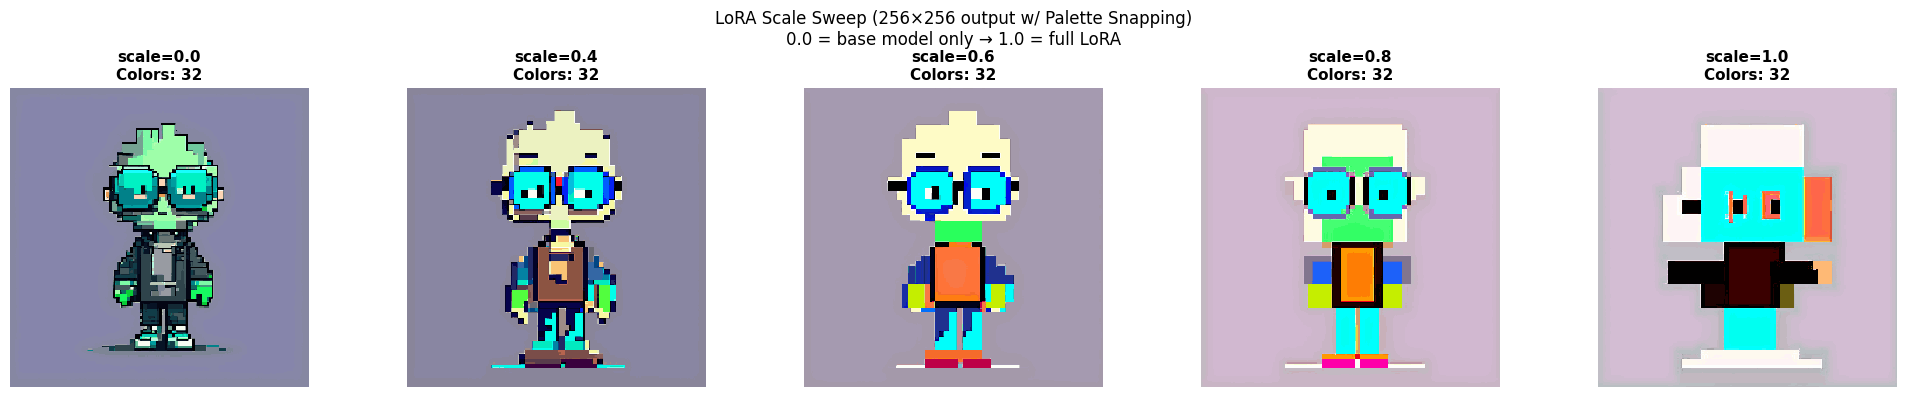

scale=0.0 → pure SSD-1B, no pixel art
scale=1.0 → max LoRA, risk of ignoring text attributes
Sweet spot is typically 0.6–0.8, adjust based on results


In [11]:
# ============================================================
# DIAGNOSTIC: Compare LoRA scales — find the sweet spot
# Sweep shows the style vs text tradeoff.
# ============================================================

import torch
from diffusers import DiffusionPipeline
from PIL import Image
import matplotlib.pyplot as plt
import os
import sys

# Import custom metric for palette snapping
from validation_metrics import apply_kmeans_palette, calculate_color_count

pipe = DiffusionPipeline.from_pretrained(
    "segmind/SSD-1B",
    torch_dtype=torch.float16,
    variant="fp16"
)
pipe.to("cuda")

lora_path = "/kaggle/working/court_of_owls_lora_v3/pytorch_lora_weights.safetensors"
if os.path.exists(lora_path):
    pipe.load_lora_weights(lora_path, adapter_name="pixel_art")
else:
    print("Warning: LoRA weights v3 not found. Check path!")

# Include the required style prefix!
test_prompt = "pixel art style, a character with circular blue glasses, a square-shaped head and a teal-colored body on a cool background"

# Sweep LoRA scales
scales = [0.0, 0.4, 0.6, 0.8, 1.0]
results_256 = []

for scale in scales:
    pipe.set_adapters(["pixel_art"], adapter_weights=[scale])
    img = pipe(
        prompt=test_prompt,
        num_inference_steps=40,
        guidance_scale=5.0,
        generator=torch.Generator("cuda").manual_seed(42)
    ).images[0]
    
    # Downscale and apply Pipeline B (nearest neighbor + K-means) for best diagnostic
    img_256 = img.resize((256, 256), resample=Image.NEAREST)
    img_256 = apply_kmeans_palette(img_256, n_colors=32)
    results_256.append(img_256)

# Display at 256×256
fig, axes = plt.subplots(1, len(scales), figsize=(4 * len(scales), 4))
for ax, img, scale in zip(axes, results_256, scales):
    ax.imshow(img, interpolation='nearest')
    color_cnt = calculate_color_count(img)
    ax.set_title(f"scale={scale}\nColors: {color_cnt}", fontsize=11, fontweight='bold')
    ax.axis('off')
    
plt.suptitle("LoRA Scale Sweep (256×256 output w/ Palette Snapping)\n0.0 = base model only → 1.0 = full LoRA", fontsize=12)
plt.tight_layout()

os.makedirs("/kaggle/working/output", exist_ok=True)
plt.savefig("/kaggle/working/output/lora_scale_sweep_256.png", dpi=150, bbox_inches='tight')
plt.show()

print("scale=0.0 → pure SSD-1B, no pixel art")
print("scale=1.0 → max LoRA, risk of ignoring text attributes")
print("Sweet spot is typically 0.6–0.8, adjust based on results")